# Physical-device Profiling

This notebook aggregates the profiling exports collected on the Redmi Note 10 Pro and generates the tables and figures used in Chapter 6. It does not run the Android benchmark itself. The raw CSV exports are stored under `ml/evaluation/profiling/raw`.

The inference experiment contains three runs. Each run contains 10 warm-up windows and 100 measured windows. Warm-up rows are validated and excluded from every reported latency statistic. The FL experiment uses 20 balanced feedback examples, two local epochs, and a batch size of eight.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "ml" / "evaluation" / "profiling" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate the MindWave repository root")

ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.evaluation.device_profiling_analysis import (
    PLOTS,
    RAW,
    configure_style,
    load_inference_runs,
    plot_fl_latency,
    plot_inference_latency,
    plot_inference_run_stability,
    plot_resource_summary,
    summarize_fl,
    summarize_inference,
    summarize_resources,
    validate_inference_runs,
)

pd.set_option("display.max_columns", None)
configure_style()
print(f"Repository root: {ROOT}")


Repository root: C:\Users\daniion6\AndroidStudioProjects\MindWave


## Device and Test Conditions

The build was profiled while connected over USB, with the screen on and synthetic windows injected back-to-back. These conditions isolate phone-side processing after a complete sensor window is available. They do not measure watch sensing, Wear Data Layer transfer, normal idle utilization, or battery drain.


In [2]:
metadata = pd.read_csv(RAW / "device_profile_metadata.csv")
display(metadata)


,property,value
0,device,Redmi Note 10 Pro
1,model,M2101K6G
2,android_version,13 (TKQ1.221013.002)
3,soc,Qualcomm Snapdragon 732G; octa-core; up to 2.3...
4,abi,arm64-v8a
5,nominal_ram_gb,6
6,reported_ram_mb,5569
7,build_type,debug
8,power_state,USB charging
9,screen_state,on


## Inference-pipeline Validation

Every raw run is checked before aggregation. The ten warm-up rows in each run are retained for provenance but excluded from the reported results.


In [3]:
inference_runs = load_inference_runs()
run_counts = validate_inference_runs(inference_runs)
display(run_counts)

assert len(run_counts) == 3
assert (run_counts["Measured"] == 100).all()
assert (run_counts["Warm-up"] == 10).all()
assert int(inference_runs["isWarmup"].eq(0).sum()) == 300


,run,Measured,Warm-up
0,1,100,10
1,2,100,10
2,3,100,10


## Phone-side Latency

Latency is measured with `SystemClock.elapsedRealtimeNanos()` around feature extraction, normalization, TFLite inference, explanation generation, Room persistence, and immediate alert-policy evaluation. Percentiles are calculated over the 300 measured windows.


In [4]:
inference_summary, inference_run_summary = summarize_inference(inference_runs)
display(inference_summary.round(3))
display(inference_run_summary.round(3))


,stage,count,mean_ms,median_ms,p95_ms,p99_ms,max_ms
0,Feature extraction,300,3.770,3.544,6.719,12.914,16.370
1,Normalization,300,0.234,0.178,0.569,0.695,4.848
2,TFLite inference,300,5.535,5.155,9.260,15.845,23.775
3,XAI generation,300,4.832,4.686,8.365,12.635,19.038
4,Room persistence,300,20.150,19.876,30.440,41.168,47.962
5,Alert-policy evaluation,300,104.731,105.876,124.493,131.054,179.816
6,Complete pipeline,300,139.255,141.179,163.505,182.412,241.471


,run,measured_windows,mean_ms,median_ms,p95_ms,p99_ms,max_ms
0,1,100,143.112,143.338,162.736,174.862,188.242
1,2,100,136.975,139.742,162.769,171.935,241.471
2,3,100,137.678,139.829,171.348,182.412,186.584


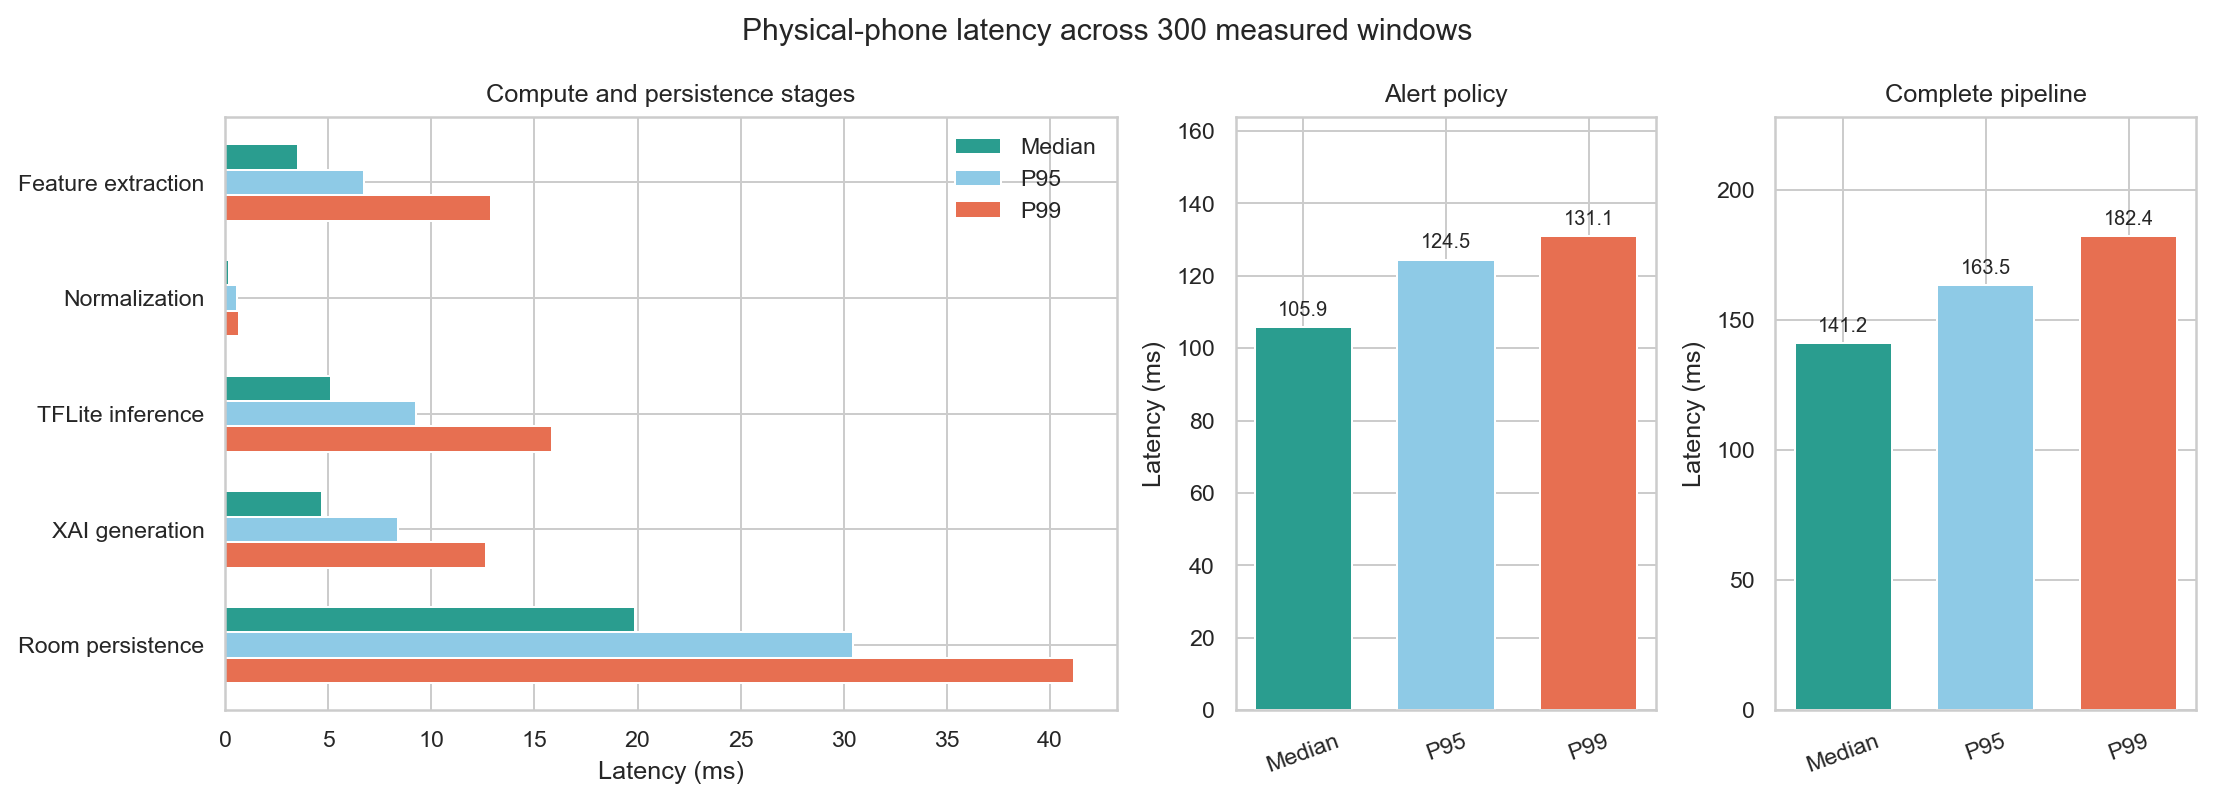

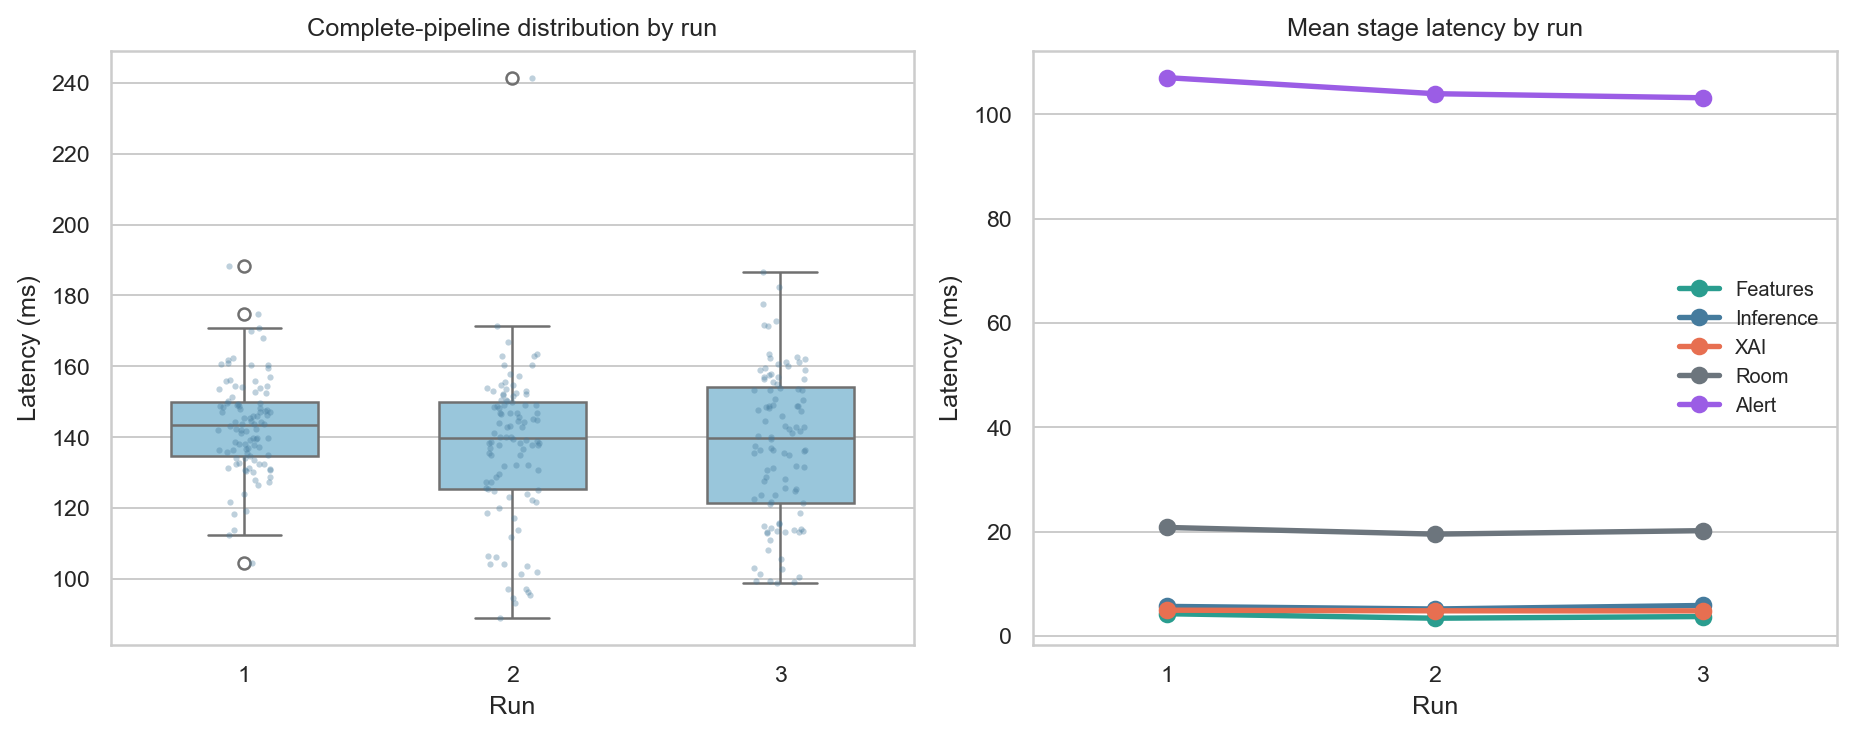

In [5]:
measured_count = int(inference_runs["isWarmup"].eq(0).sum())
plot_inference_latency(inference_summary, measured_count)
plot_inference_run_stability(inference_runs)
display(Image(filename=str(PLOTS / "device_inference_latency.png")))
display(Image(filename=str(PLOTS / "device_inference_run_stability.png")))


The `MW.alert` Perfetto slices are not used for the latency table because the measured function is suspending and Android trace sections are thread-local. Coroutine suspension or thread migration can therefore inflate individual slice durations. The monotonic wall-time records persisted by the application are used instead.


## Federated-learning Profiling

Four local-training executions were captured. The first execution is cold and includes initial model/delegate setup. The other three reuse initialized state. `local_wall_ms` covers load, restore, train, and weight save. Upload is reported separately, and the estimated end-to-end value adds the measured upload duration to the local wall time.


,run,run_type,load_ms,restore_ms,train_ms,save_ms,upload_ms,local_wall_ms,local_phase_sum_ms,estimated_end_to_end_ms
0,1,Cold,134.890,23.450,98.410,0.198,125.320,257.746,256.948,383.066
1,2,Warm,38.445,7.813,82.776,0.079,39.344,129.657,129.113,169.001
2,3,Warm,36.280,6.594,73.686,0.085,37.220,117.114,116.645,154.334
3,4,Warm,38.054,6.351,76.914,0.081,39.435,121.911,121.400,161.346


,run_type,load_ms,restore_ms,train_ms,save_ms,upload_ms,local_wall_ms,estimated_end_to_end_ms
0,Cold,134.890,23.450,98.410,0.198,125.320,257.746,383.066
1,Warm mean,37.593,6.919,77.792,0.082,38.666,122.894,161.560


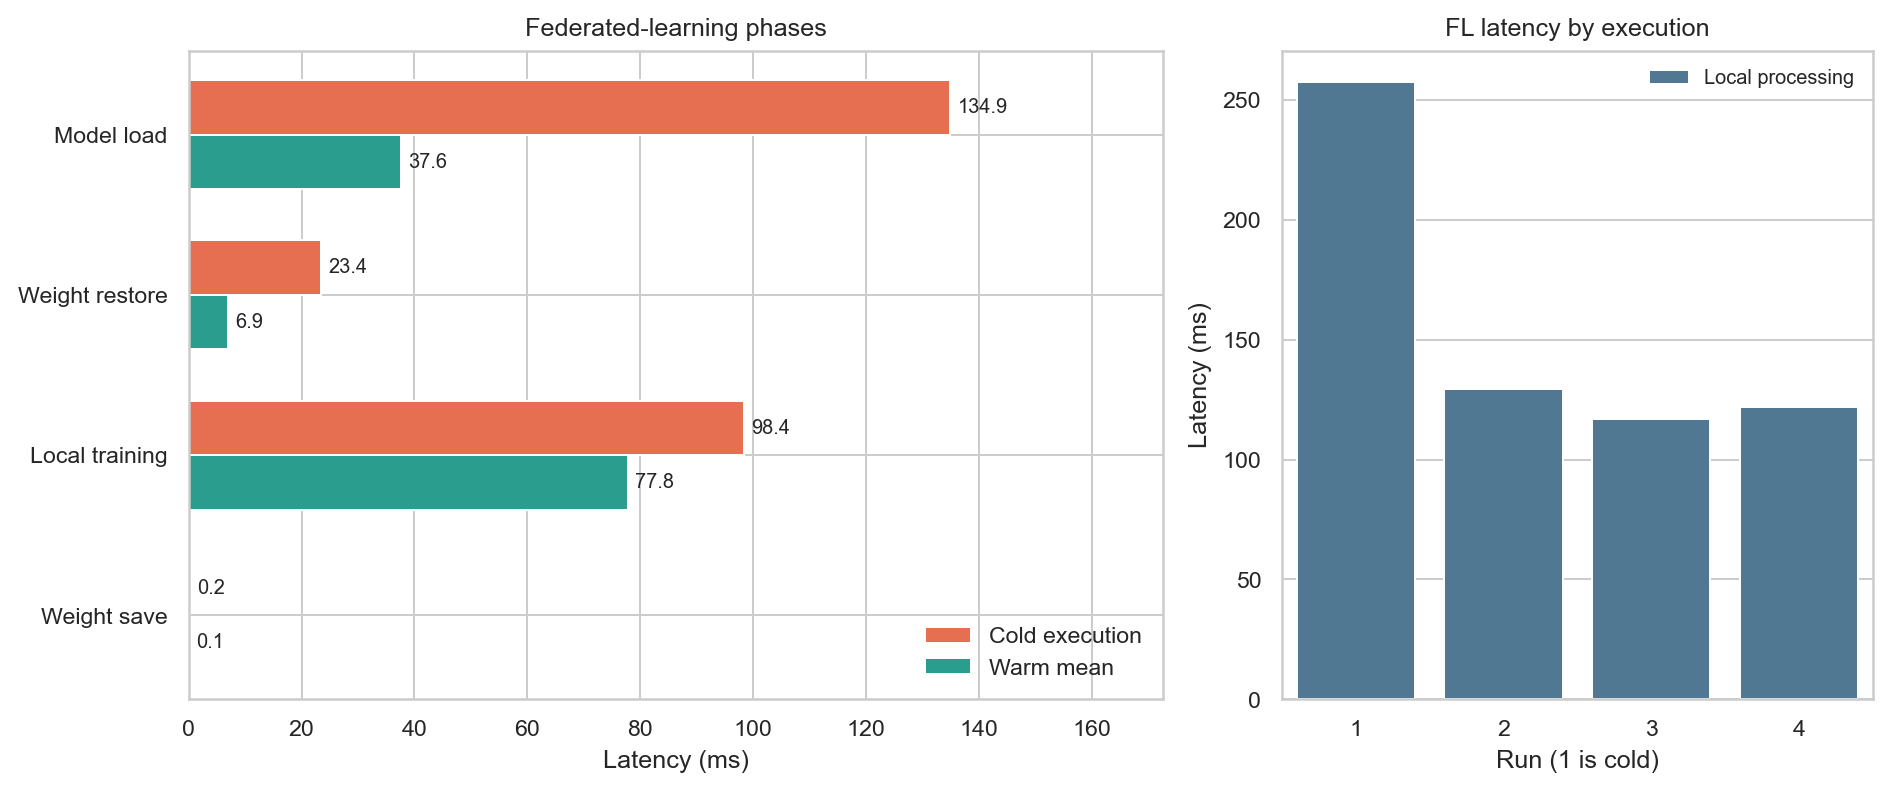

In [6]:
fl_runs, fl_summary = summarize_fl()
display(fl_runs.round(3))
display(fl_summary.round(3))

plot_fl_latency(fl_runs, fl_summary)
display(Image(filename=str(PLOTS / "device_fl_phase_latency.png")))


## CPU and Memory Counters

CPU percentages are normalized to one fully occupied core. Values above 100% indicate parallel work across more than one core, not utilization above the phone's total CPU capacity. The memory values are the Java heap and HWUI counters available in the captured interval; they are not equivalent to the complete process RSS.


,scope,metric,average,peak,unit
0,Inference benchmark,Equivalent occupied CPU cores,1.194,NaN,cores
1,Cold FL run,Equivalent occupied CPU cores,1.426,NaN,cores
2,Cold FL run,Java heap size counter,12.247,12.347,MiB
3,Cold FL run,HWUI All Memory counter,21.107,21.107,MiB


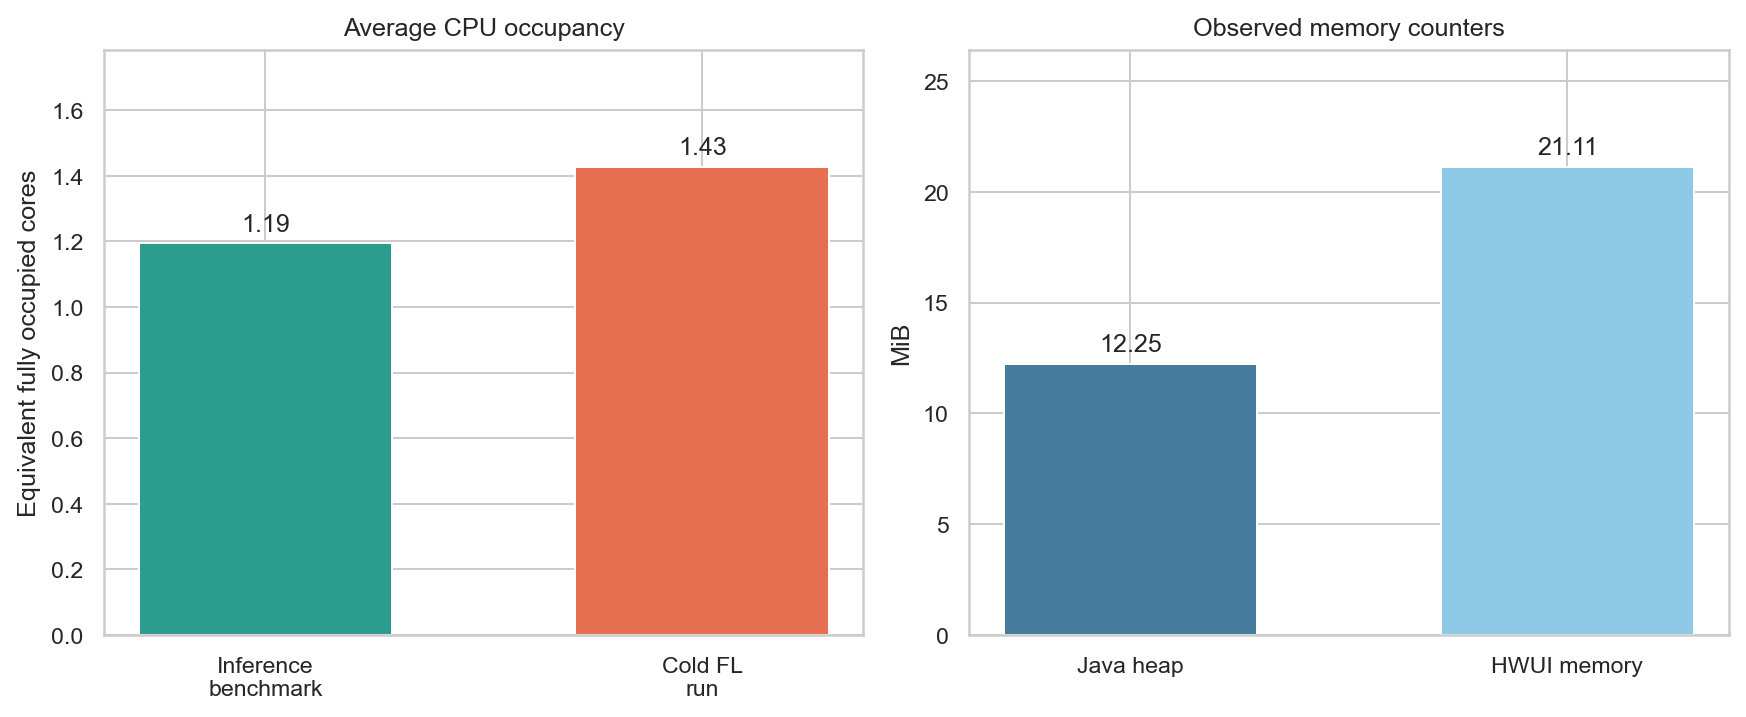

In [7]:
resource_summary = summarize_resources()
display(resource_summary.round(3))

plot_resource_summary(resource_summary)
display(Image(filename=str(PLOTS / "device_resource_summary.png")))


## Thesis-facing Interpretation

The phone-side pipeline can be compared with the latency requirement because timing starts after a complete sensor window is available. The benchmark cannot support a battery-life claim because the phone was charging over USB and the screen remained on. It also cannot be used as a watch-to-phone communication benchmark because all sensor windows were generated locally.


In [8]:
total = inference_summary.loc[
    inference_summary["stage"].eq("Complete pipeline")
].iloc[0]
alert = inference_summary.loc[
    inference_summary["stage"].eq("Alert-policy evaluation")
].iloc[0]
warm_fl = fl_summary.loc[fl_summary["run_type"].eq("Warm mean")].iloc[0]

print(f"Complete pipeline median: {total['median_ms']:.2f} ms")
print(f"Complete pipeline p95:    {total['p95_ms']:.2f} ms")
print(f"Complete pipeline p99:    {total['p99_ms']:.2f} ms")
print(f"Alert-policy median:      {alert['median_ms']:.2f} ms")
print(f"Warm FL local mean:       {warm_fl['local_wall_ms']:.2f} ms")
print(f"Warm FL incl. upload:     {warm_fl['estimated_end_to_end_ms']:.2f} ms")


Complete pipeline median: 141.18 ms
Complete pipeline p95:    163.51 ms
Complete pipeline p99:    182.41 ms
Alert-policy median:      105.88 ms
Warm FL local mean:       122.89 ms
Warm FL incl. upload:     161.56 ms
